In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys
sys.path.insert(1, '../')
from Harmonic_degree import *
from HOLR_functions import *

In [9]:
# Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
    data_2 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)
    # Open data
with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("../Clustering/GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

50


# Collab

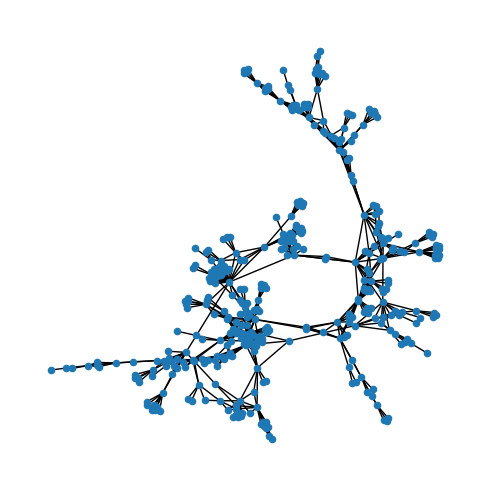

In [4]:
# Collab
Ag=data_1["NetSci Collab"]
pos=nx.spring_layout(Ag,iterations=100)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False,node_size = 20)
plt.tight_layout()

In [5]:
# Laplacian
L0=nx.laplacian_matrix(Ag, nodelist = Ag.nodes()).todense()
e,ev=np.linalg.eigh(L0)
# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 3 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)

# Harmonic Curves
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, t_h = H_CF_curves(Ag,L0,100, pow(10,-3))

c:\Users\Utente\Desktop\Harmonic_Morph_2\Laplacian\..\HOLR_functions.py:305: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))
c:\Users\Utente\anaconda3\envs\Nuovo2_net\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


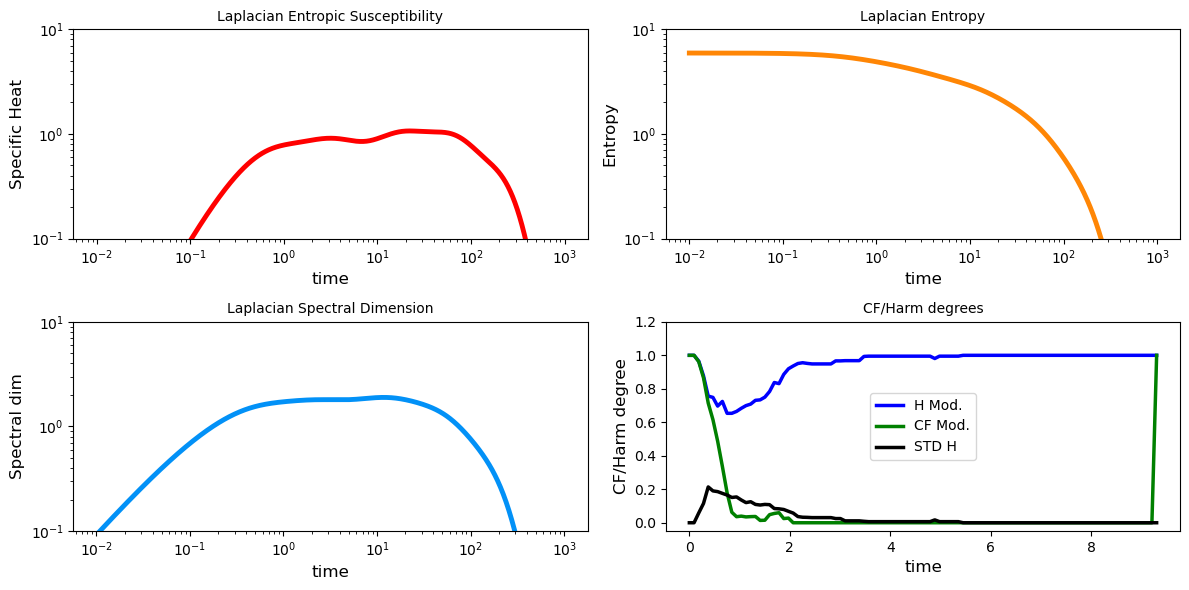

In [ ]:
f,ax = plt.subplots(2,2,figsize = (12,6))
ax=ax.flatten()
ax[0].loglog(t_e,ce, 'r', linewidth = 3.5)
ax[0].set_ylabel("Specific Heat")
ax[0].set_ylim([pow(10,-1),10])
ax[0].set_title("Laplacian Entropic Susceptibility")
ax[0].set_xlabel("time")


ax[1].loglog(t_e,se[1:],'#FF8605', linewidth = 3.5)
ax[1].set_ylabel("Entropy")
ax[1].set_ylim([pow(10,-1),10])
ax[1].set_title("Laplacian Entropy")
ax[1].set_xlabel("time")


ax[2].loglog(t_s,sd, '#0291F7', linewidth = 3.5)
ax[2].set_ylabel("Spectral dim")
ax[2].set_ylim([pow(10,-1),10])
ax[2].set_title("Laplacian Spectral Dimension")
ax[2].set_xlabel("time")


#ax[3].plot(t_h,DEG_H)
ax[3].plot(t_h,M_DEG_H, 'b', linewidth = 2.5)
#ax[3].plot(t_h,DEG_CF)
ax[3].plot(t_h,M_DEG_CF, 'g', linewidth = 2.5)
ax[3].plot(t_h,STD_H, 'k', linewidth = 2.5)
#ax[3].plot(t_h, STD_CF)
ax[3].set_ylabel("CF/Harm degree")
ax[3].set_title("CF/Harm degrees")
ax[3].legend(["H Mod.","CF Mod.", "STD H"])
ax[3].set_ylim([-0.05,1.2])
ax[3].set_xlabel("time")

plt.tight_layout()
f.savefig("NetCol_Lap_curves.pdf")

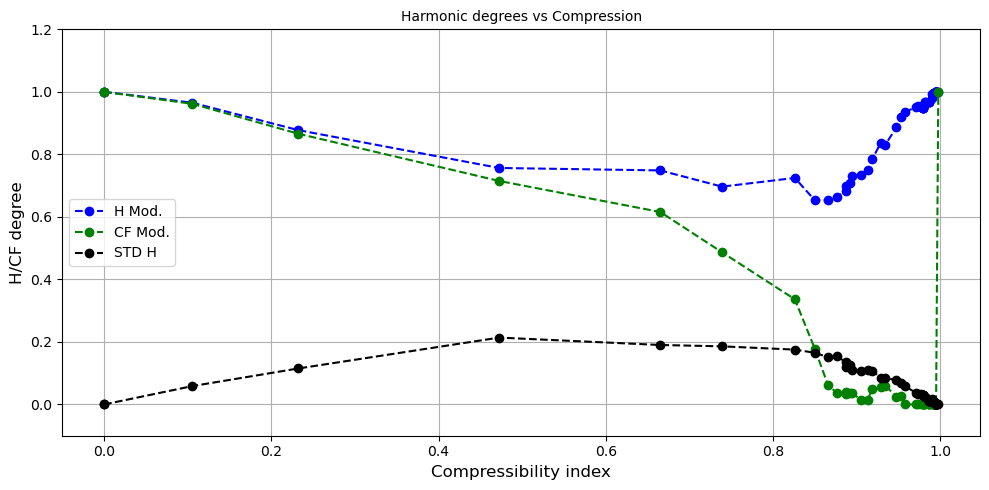

In [ ]:
l=g_len(g)
l=1-np.array(l)/len(Ag.nodes())

f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index")
plt.ylabel("H/CF degree")
plt.title("Harmonic degrees vs Compression")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("NetCol_Lap_Compr.pdf")

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.741425 0.673034 0.154918 0.007916 0.037778 1.908896


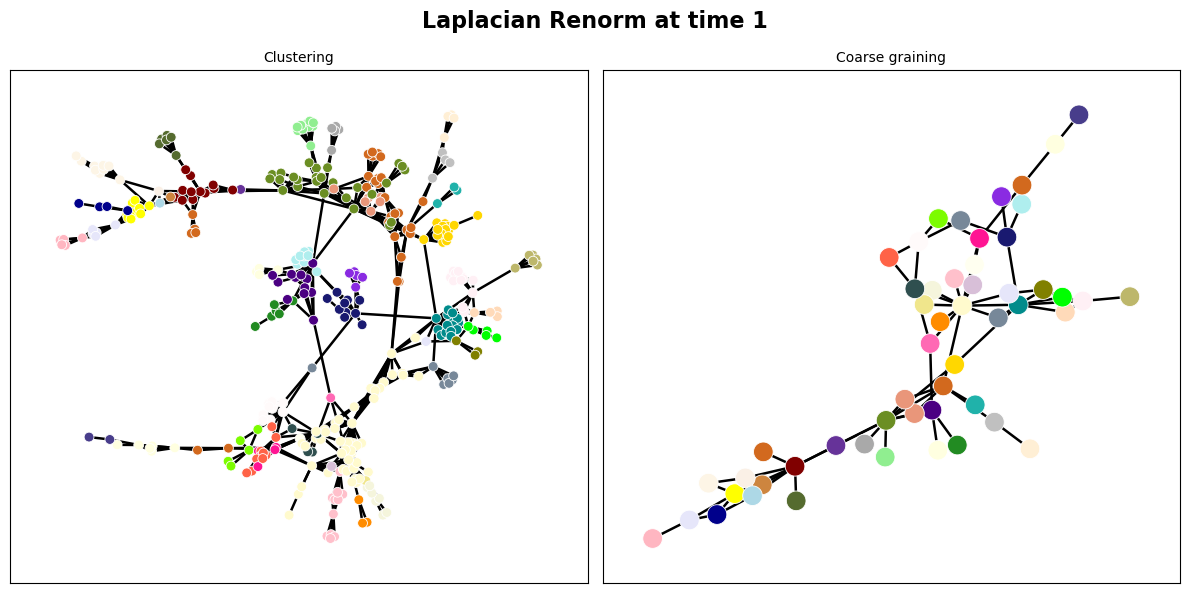

In [ ]:
# Visualization
t=1
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"NetCol_Lap_{t}.pdf")

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.656992 0.725455 0.193128 0.166227 0.550442  1.38331


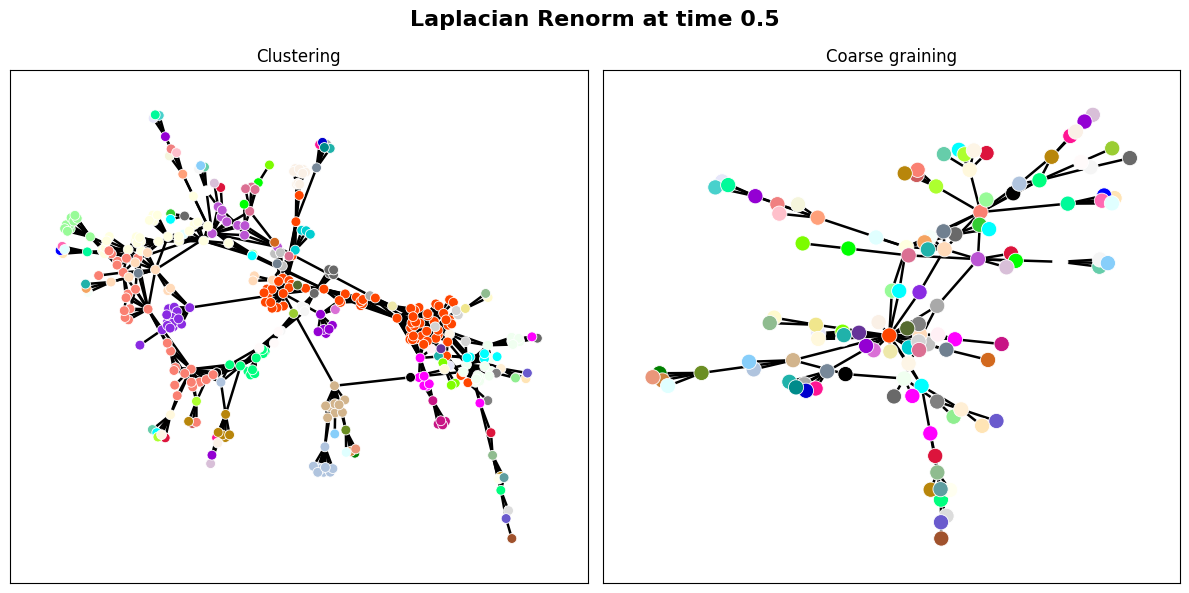

In [80]:
# Visualization
t=0.5
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 120)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"NetCol_Lap_{t}.pdf")

       H   Mod. H  Std. H       CF  Mod. CF  Std. CF
0.865435 0.919664 0.06831 0.002639 0.027778   2.1736


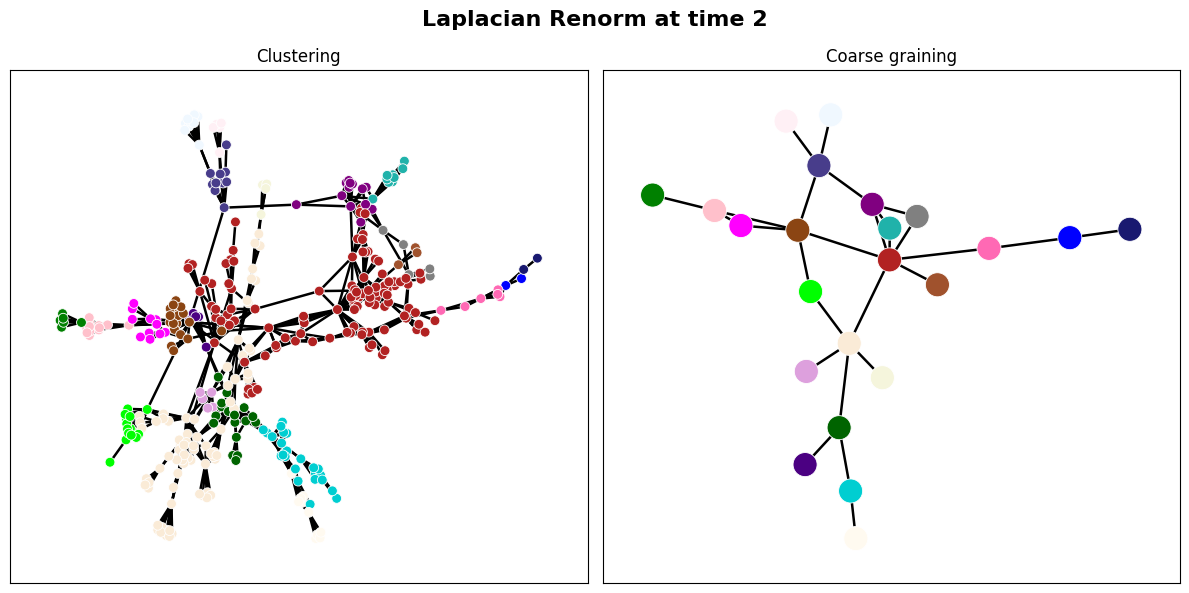

In [94]:
# Visualization
t=2
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"NetCol_Lap_{t}.pdf")

       H   Mod. H   Std. H  CF  Mod. CF  Std. CF
0.952507 0.948597 0.030714 0.0      0.0 2.531484


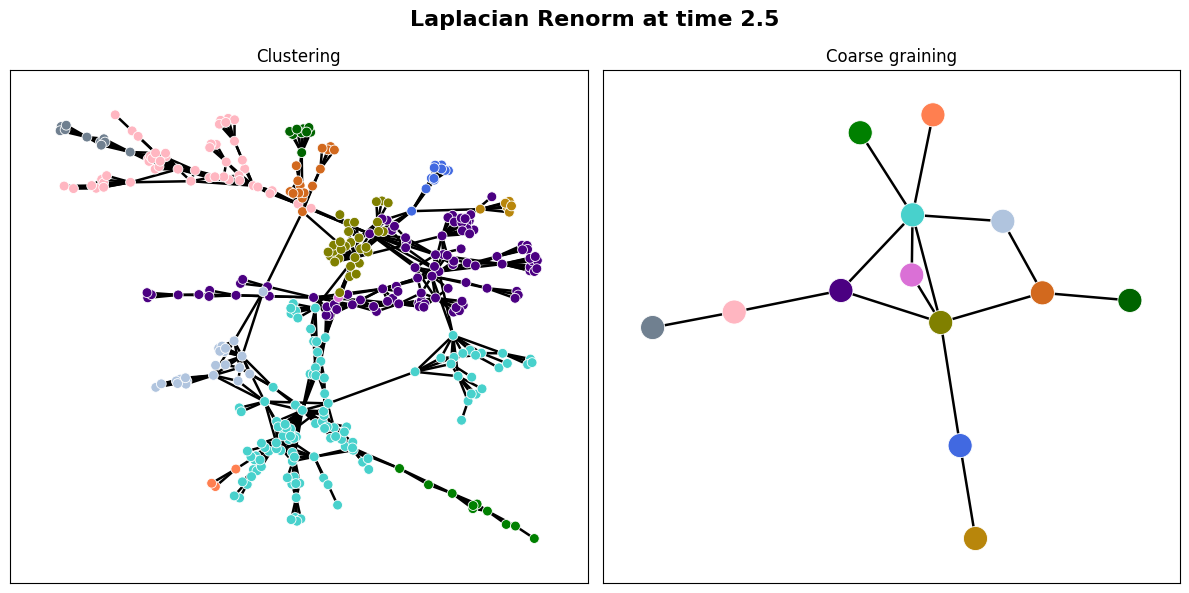

In [92]:
# Visualization
t=2.5
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"NetCol_Lap_{t}.pdf")

# Facebook

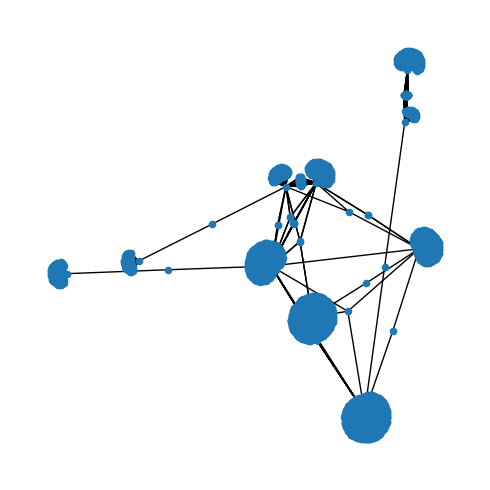

In [ ]:
# Facebook
Ag=data_1["Facebook"]
pos=nx.spring_layout(Ag,iterations=100)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False,node_size = 20)
plt.tight_layout()


In [130]:
Ag = data_1["Facebook"]
L0 = nx.laplacian_matrix(Ag).todense()

In [5]:
# Laplacian
L0=nx.laplacian_matrix(Ag).todense()
e,ev=np.linalg.eigh(L0)

# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 6 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)
# Harmonic Curves
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, t_h = H_CF_curves(Ag,L0,100, pow(10,-3))

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Utente\AppData\Local\Temp\ipykernel_16864\4254892587.py:174: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))


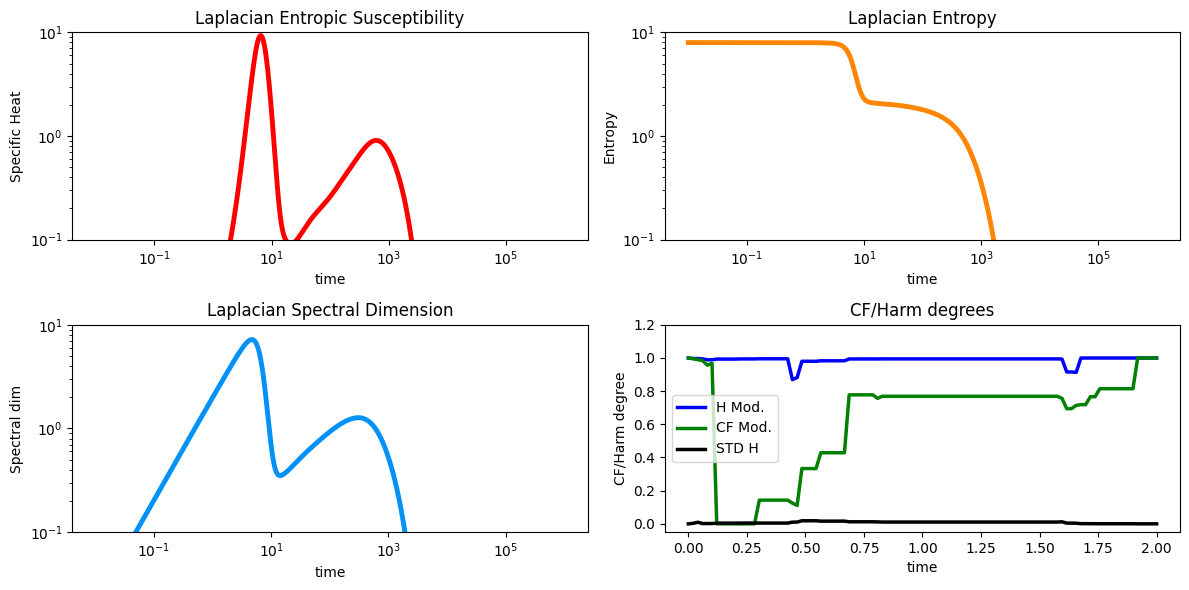

In [7]:
f,ax = plt.subplots(2,2,figsize = (12,6))
ax=ax.flatten()
ax[0].loglog(t_e,ce, 'r', linewidth = 3.5)
ax[0].set_ylabel("Specific Heat")
ax[0].set_ylim([pow(10,-1),10])
ax[0].set_title("Laplacian Entropic Susceptibility")
ax[0].set_xlabel("time")


ax[1].loglog(t_e,se[1:],'#FF8605', linewidth = 3.5)
ax[1].set_ylabel("Entropy")
ax[1].set_ylim([pow(10,-1),10])
ax[1].set_title("Laplacian Entropy")
ax[1].set_xlabel("time")


ax[2].loglog(t_s,sd, '#0291F7', linewidth = 3.5)
ax[2].set_ylabel("Spectral dim")
ax[2].set_ylim([pow(10,-1),10])
ax[2].set_title("Laplacian Spectral Dimension")
ax[2].set_xlabel("time")


#ax[3].plot(t_h,DEG_H)
ax[3].plot(t_h,M_DEG_H, 'b', linewidth = 2.5)
#ax[3].plot(t_h,DEG_CF)
ax[3].plot(t_h,M_DEG_CF, 'g', linewidth = 2.5)
ax[3].plot(t_h,STD_H, 'k', linewidth = 2.5)
#ax[3].plot(t_h, STD_CF)
ax[3].set_ylabel("CF/Harm degree")
ax[3].set_title("CF/Harm degrees")
ax[3].legend(["H Mod.","CF Mod.", "STD H"])
ax[3].set_ylim([-0.05,1.2])
ax[3].set_xlabel("time")

plt.tight_layout()
f.savefig("FB_Lap_curves.pdf")

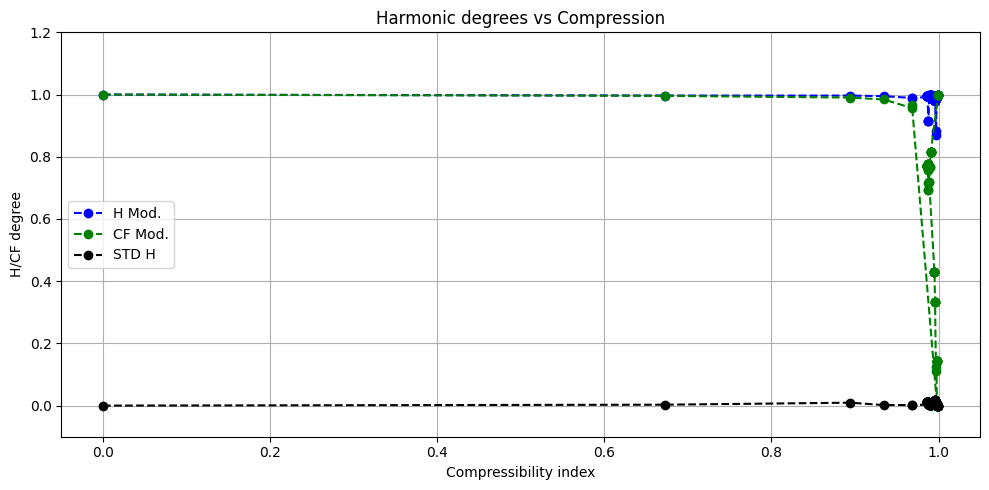

In [8]:
l=g_len(g)
l=1-np.array(l)/len(Ag.nodes())

f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index")
plt.ylabel("H/CF degree")
plt.title("Harmonic degrees vs Compression")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("FB_Lap_Compr.pdf")

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.981302 0.994627 0.010694 0.010388 0.769231 0.983798


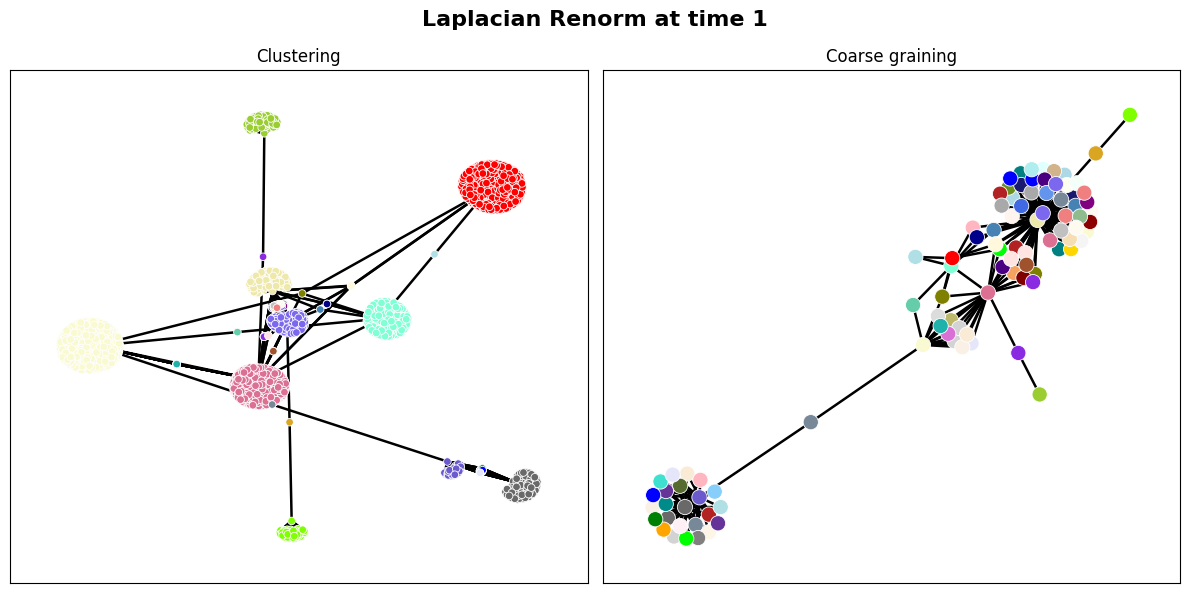

In [26]:
# Visualization
t=1
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 120)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"FB_Lap_{t}.pdf")

  H  Mod. H  Std. H  CF  Mod. CF  Std. CF
1.0     1.0     0.0 1.0      1.0      0.0


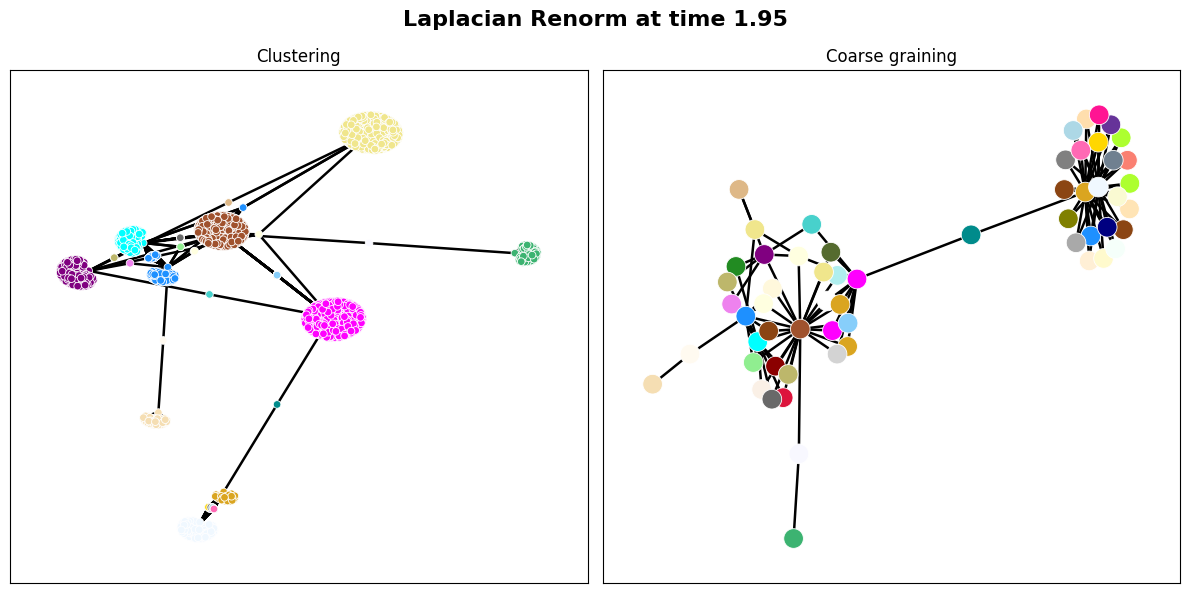

In [32]:
# Visualization
t=1.95
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-3))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"FB_Lap_{t}.pdf")

# C. Elegans

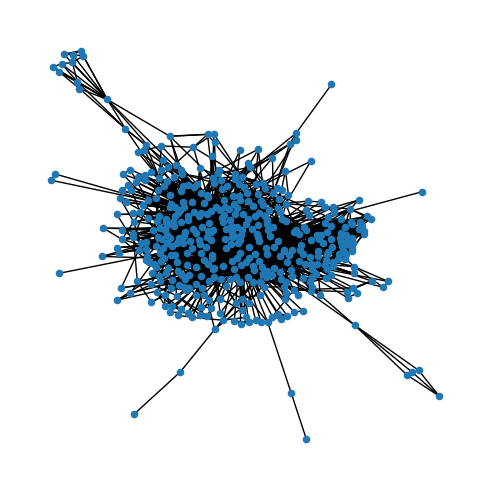

In [10]:
# C.Elegans
Ag=data_1["C. Elegans"]
pos=nx.spring_layout(Ag,iterations=100)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False,node_size = 20)
plt.tight_layout()

In [121]:
# Laplacian
L0=nx.laplacian_matrix(Ag).todense()
e,ev=np.linalg.eigh(L0)

# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 2 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# computing entropic quantities: entropy and entropic subsceptibility
ce,t_e,se=compute_entropic_C(e,exm,exM,n_t)

# computing spectral dimension
sd,t_s=compute_spectral_d(e,exm,exM,n_t)

# Harmonic Curves
g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, t_h = H_CF_curves(Ag,L0,100)

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Utente\AppData\Local\Temp\ipykernel_16864\4254892587.py:174: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))


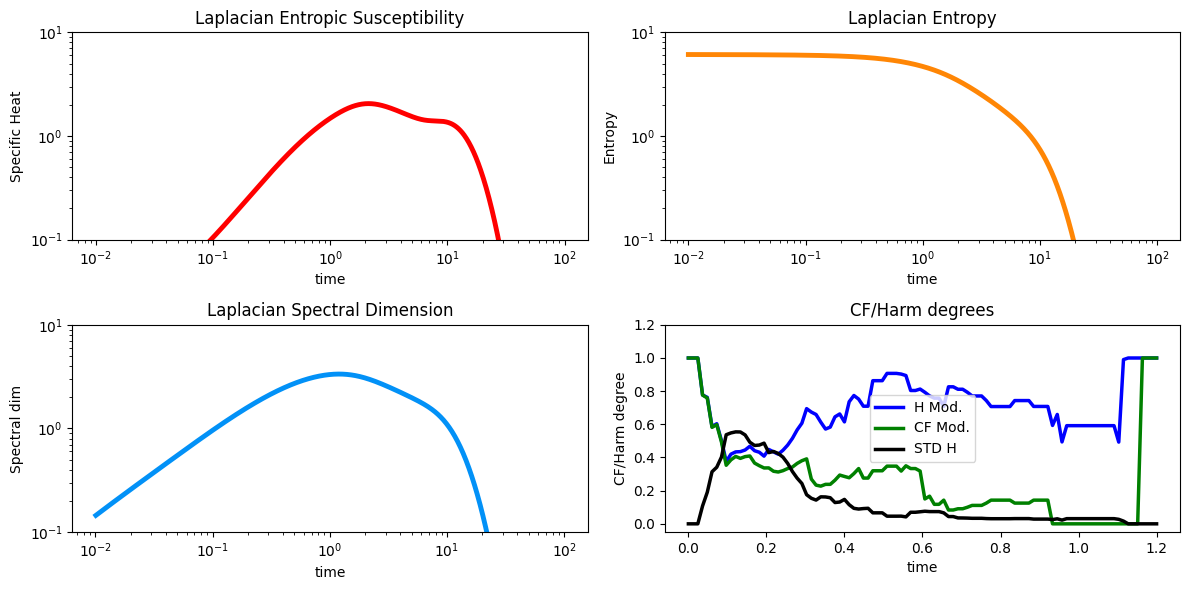

In [36]:
f,ax = plt.subplots(2,2,figsize = (12,6))
ax=ax.flatten()
ax[0].loglog(t_e,ce, 'r', linewidth = 3.5)
ax[0].set_ylabel("Specific Heat")
ax[0].set_ylim([pow(10,-1),10])
ax[0].set_title("Laplacian Entropic Susceptibility")
ax[0].set_xlabel("time")


ax[1].loglog(t_e,se[1:],'#FF8605', linewidth = 3.5)
ax[1].set_ylabel("Entropy")
ax[1].set_ylim([pow(10,-1),10])
ax[1].set_title("Laplacian Entropy")
ax[1].set_xlabel("time")


ax[2].loglog(t_s,sd, '#0291F7', linewidth = 3.5)
ax[2].set_ylabel("Spectral dim")
ax[2].set_ylim([pow(10,-1),10])
ax[2].set_title("Laplacian Spectral Dimension")
ax[2].set_xlabel("time")


#ax[3].plot(t_h,DEG_H)
ax[3].plot(t_h,M_DEG_H, 'b', linewidth = 2.5)
#ax[3].plot(t_h,DEG_CF)
ax[3].plot(t_h,M_DEG_CF, 'g', linewidth = 2.5)
ax[3].plot(t_h,STD_H, 'k', linewidth = 2.5)
#ax[3].plot(t_h, STD_CF)
ax[3].set_ylabel("CF/Harm degree")
ax[3].set_title("CF/Harm degrees")
ax[3].legend(["H Mod.","CF Mod.", "STD H"])
ax[3].set_ylim([-0.05,1.2])
ax[3].set_xlabel("time")

plt.tight_layout()
f.savefig("Ce_Lap_curves.pdf")

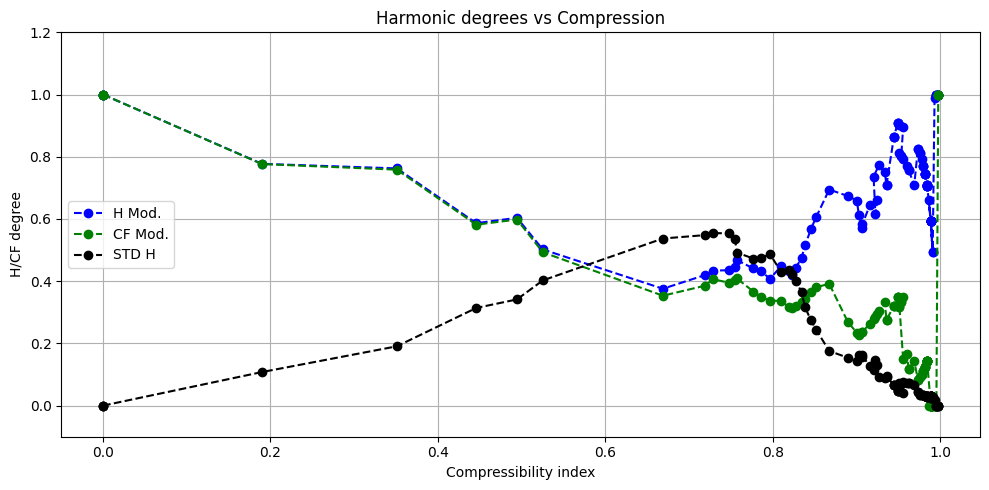

In [37]:
l=g_len(g)
l=1-np.array(l)/len(Ag.nodes())

f=plt.figure(figsize=(10,5))
#plt.plot(l,DEG_H,"or--")
plt.plot(l,M_DEG_H,"ob--")
#plt.plot(l,DEG_CF,"oy--")
plt.plot(l,M_DEG_CF,"og--")
plt.plot(l,STD_H,"ok--")
plt.xlabel("Compressibility index")
plt.ylabel("H/CF degree")
plt.title("Harmonic degrees vs Compression")
plt.legend(["H Mod.","CF Mod.","STD H"])
plt.ylim([-0.1,1.2])
plt.grid()
plt.tight_layout()
f.savefig("Ce_Lap_Compr.pdf")

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.571744 0.735614 0.165703 0.514349 0.735016 0.244729


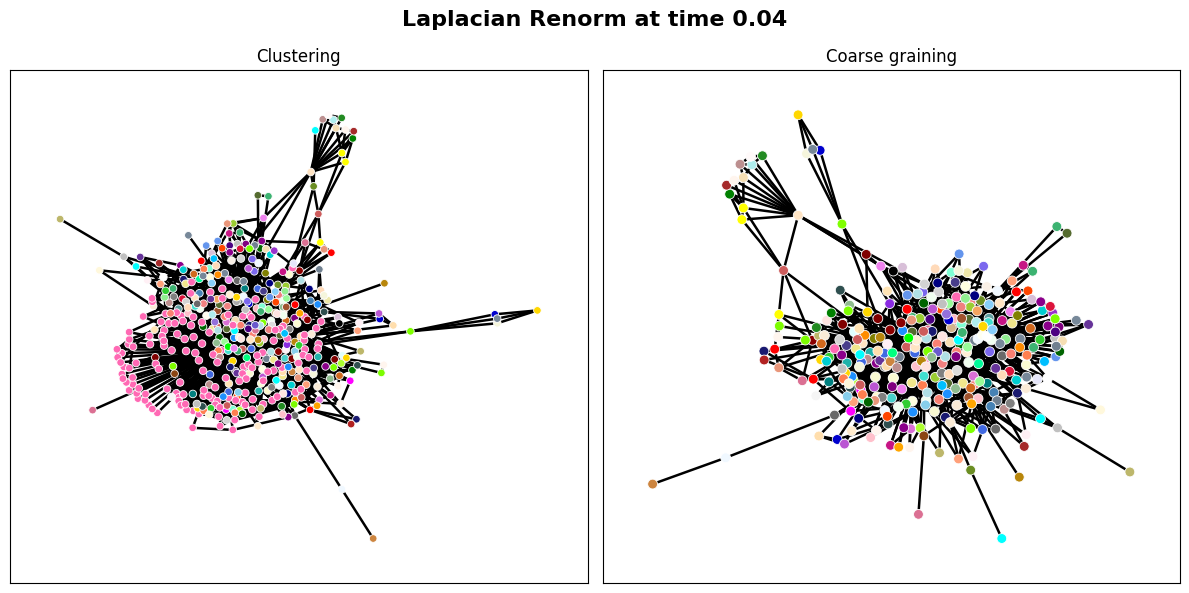

In [64]:
# Visualization
t=0.04
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 50)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Ce_Lap_{t}.pdf")

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.951435 0.973119 0.014424 0.905077 0.971564 0.035487


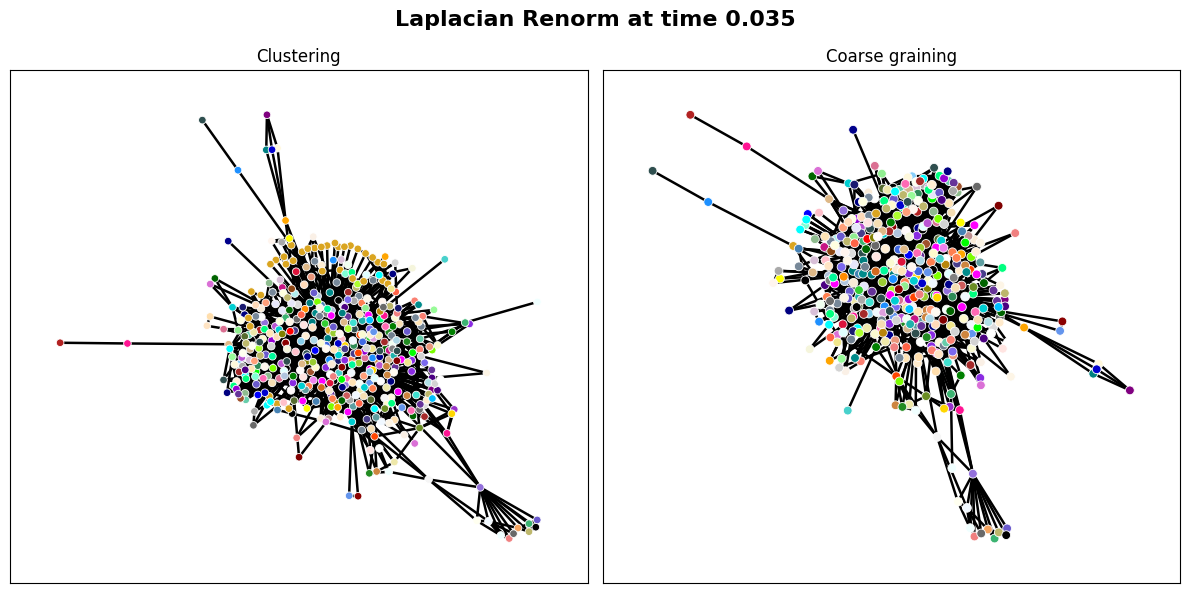

In [66]:
# Visualization
t=0.035
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 40)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Ce_Lap_{t}.pdf")

       H   Mod. H   Std. H      CF  Mod. CF  Std. CF
0.364238 0.374907 0.538158 0.11479 0.358621 0.924788


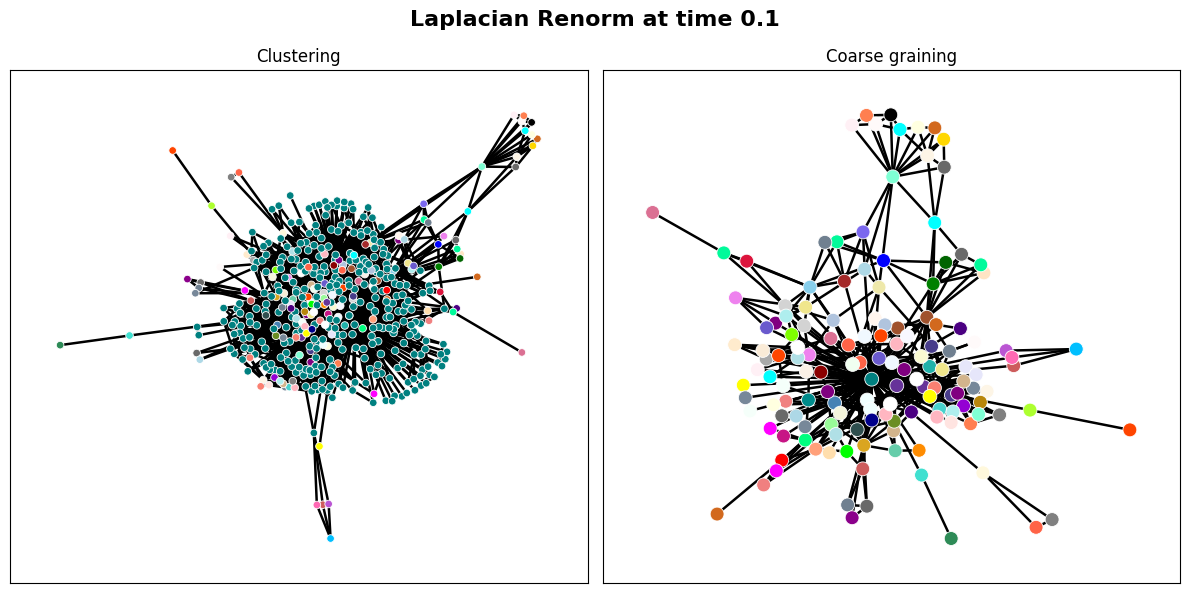

In [124]:
# Visualization
t=0.1
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 100)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Ce_Lap_{t}.pdf")

       H  Mod. H   Std. H       CF  Mod. CF  Std. CF
0.660044 0.61027 0.243684 0.057395 0.392308 1.418076


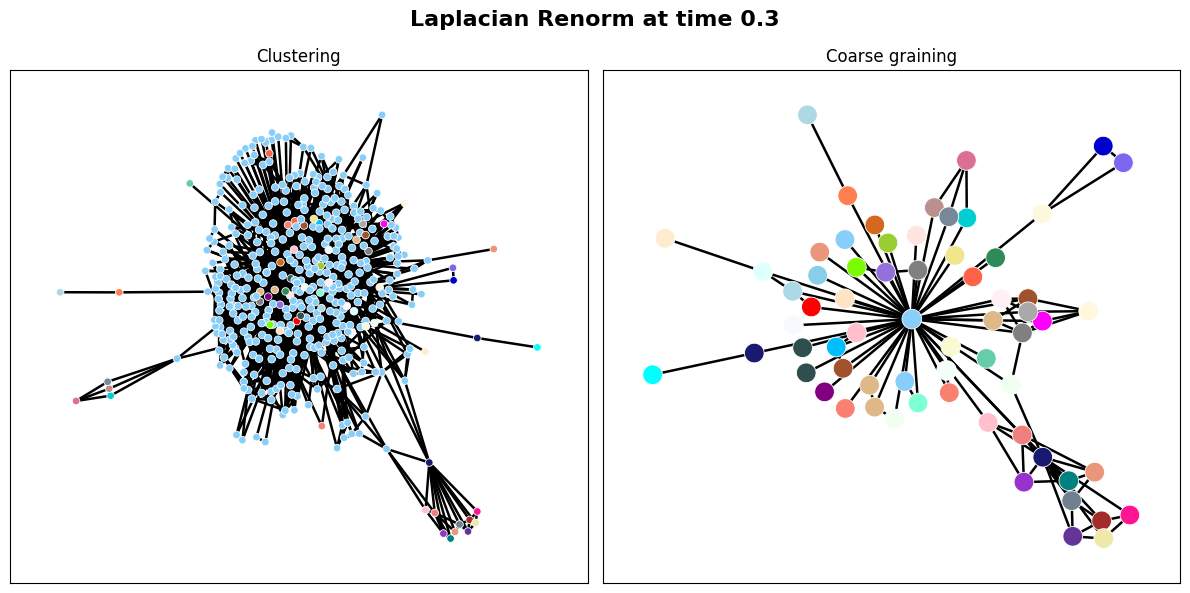

In [129]:
# Visualization
t=0.3
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig(f"Ce_Lap_{t}.pdf")